In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [82]:
df = pd.read_csv('ai_student_impact_dataset.csv')
df.head(20)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [83]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [84]:
#missing values
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [85]:
#duplicate values
df.duplicated().sum()



np.int64(0)

In [86]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

Burnout_Risk_Level
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


The number of students that paid for an AI subscription.

In [87]:
df['Paid_Subscription'].value_counts()


Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

**Comparing the GPA pre and post semester.**

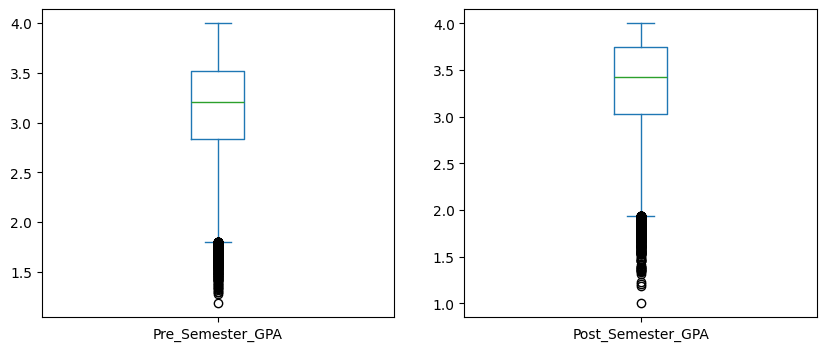

In [88]:
df[['Pre_Semester_GPA', 'Post_Semester_GPA']].describe()

df[['Pre_Semester_GPA', 'Post_Semester_GPA']].plot(
    kind='box',
    subplots=True,
    layout=(1, 2),
    figsize=(10, 4)
)

plt.show()

In [89]:
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']
df['GPA_Change'].describe()
df[['Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_Change']].head(10)

,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change
0,2.418,2.393,-0.025
1,3.821,3.696,-0.125
2,3.398,3.499,0.101
3,3.789,4.000,0.211
4,3.635,3.798,0.163
5,3.449,3.666,0.217
6,3.622,4.000,0.378
7,2.746,2.965,0.219
8,3.420,3.396,-0.024
9,3.046,2.978,-0.068


What do students use AI most for?

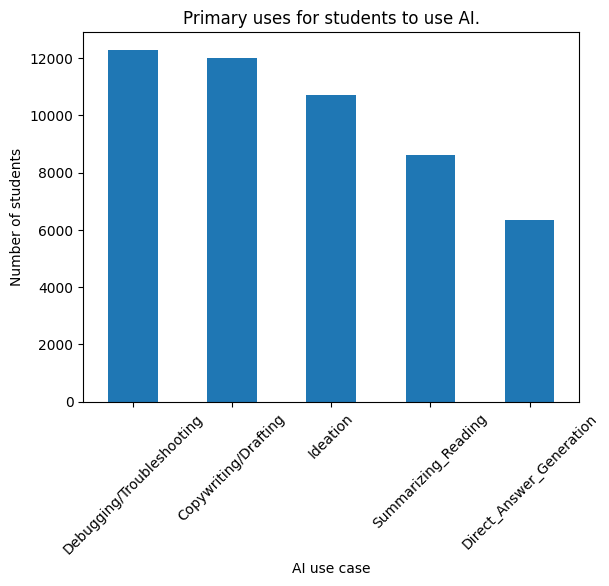

count    50000.000000
mean         8.427752
std          8.269490
min          0.000000
25%          2.390000
50%          5.800000
75%         11.720000
max         40.000000
Name: Weekly_GenAI_Hours, dtype: float64

In [90]:
df['Primary_Use_Case'].value_counts().plot(kind = 'bar')

plt.title('Primary uses for students to use AI.')
plt.xlabel('AI use case')
plt.ylabel('Number of students')
plt.xticks(rotation = 45)
plt.show()

df['Weekly_GenAI_Hours'].describe()


How many weekly hours are students using GenAI?

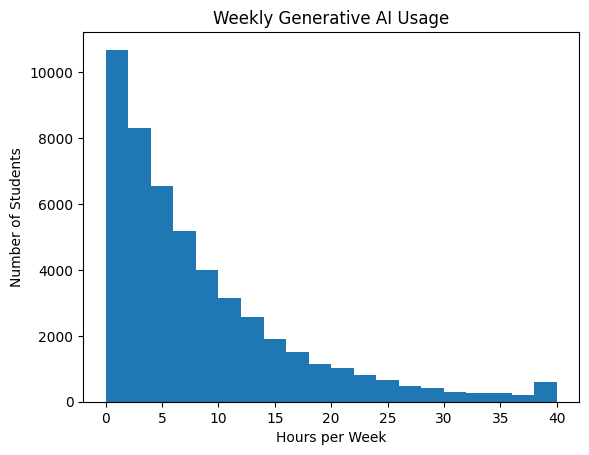

In [91]:

df['Weekly_GenAI_Hours'].plot(kind='hist', bins=20)

plt.title('Weekly Generative AI Usage')
plt.xlabel('Hours per Week')
plt.ylabel('Number of Students')
plt.show()

Does AI impact the students GPA?

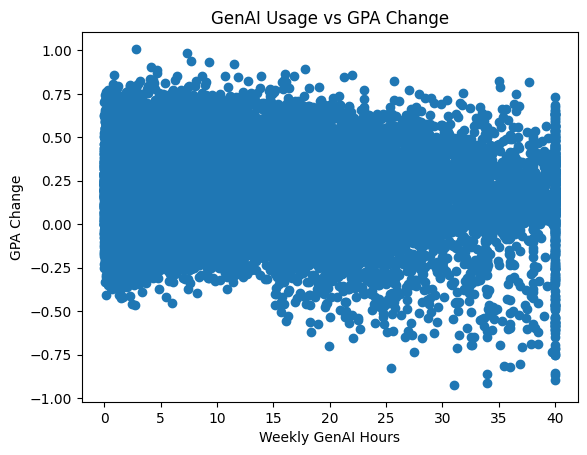

np.float64(-0.04647928314059735)

In [92]:

plt.scatter(df['Weekly_GenAI_Hours'], df['GPA_Change'])

plt.title('GenAI Usage vs GPA Change')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('GPA Change')
plt.show()

df['Weekly_GenAI_Hours'].corr(df['GPA_Change'])

Is traditional study time more strongly associated with GPA change than AI usage?

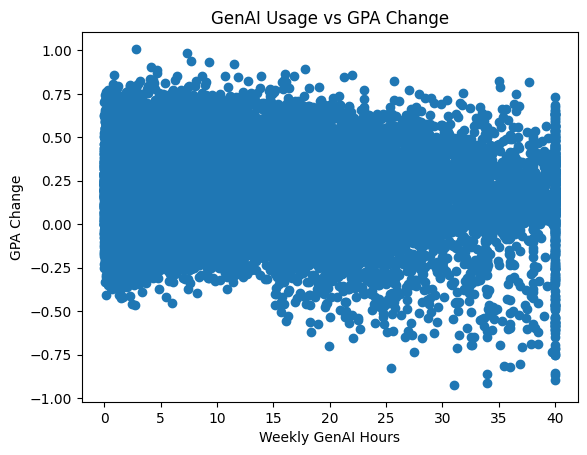

In [93]:

plt.scatter(df['Weekly_GenAI_Hours'], df['GPA_Change'])

plt.title('GenAI Usage vs GPA Change')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('GPA Change')
plt.show()


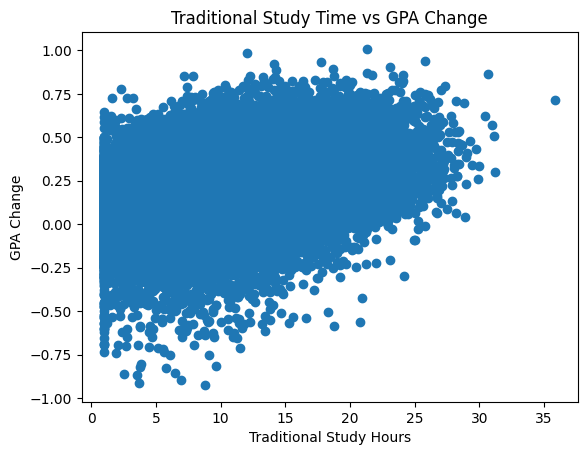

In [94]:
plt.scatter(df['Traditional_Study_Hours'], df['GPA_Change'])

plt.title('Traditional Study Time vs GPA Change')
plt.xlabel('Traditional Study Hours')
plt.ylabel('GPA Change')
plt.show()


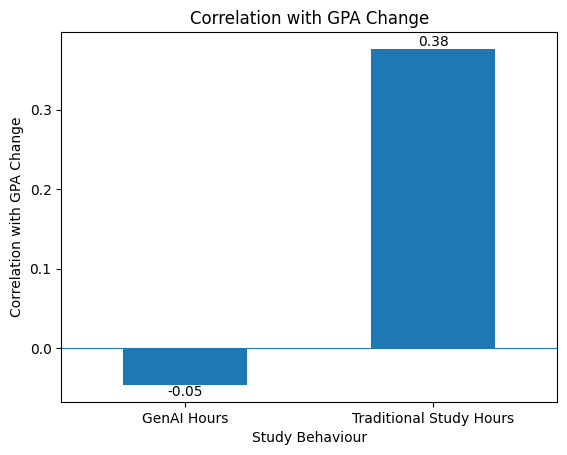

In [95]:
correlations = pd.Series({
    'GenAI Hours': df['Weekly_GenAI_Hours'].corr(df['GPA_Change']),
    'Traditional Study Hours': df['Traditional_Study_Hours'].corr(df['GPA_Change'])
})

correlations


correlations.plot(kind='bar')

plt.title('Correlation with GPA Change')
plt.xlabel('Study Behaviour')
plt.ylabel('Correlation with GPA Change')
plt.xticks(rotation=0)
plt.axhline(0, linewidth=0.8)
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.show()


The correlation between GPA change and GenAi is -0.05 while for traditional study usage is 0.38. This suggests that traditional study time has a stronger linear association with GPA change in the dataset. And while the graph shows that traditional study hours has a positive correlation with GPA changed compared to GenAI hours which has a negative correlation with GPA change, this does not imedialy show that one is better than the other as the GPA change could be negative.

Is percived AI dependency associated with student's skill retention? 

In [96]:
df.groupby('Perceived_AI_Dependency')['Skill_Retention_Score'].mean()

Perceived_AI_Dependency
1     75.997832
2     76.477936
3     76.483281
4     76.354022
5     75.851789
6     74.901460
7     72.471852
8     69.400339
9     65.555582
10    63.547474
Name: Skill_Retention_Score, dtype: float64

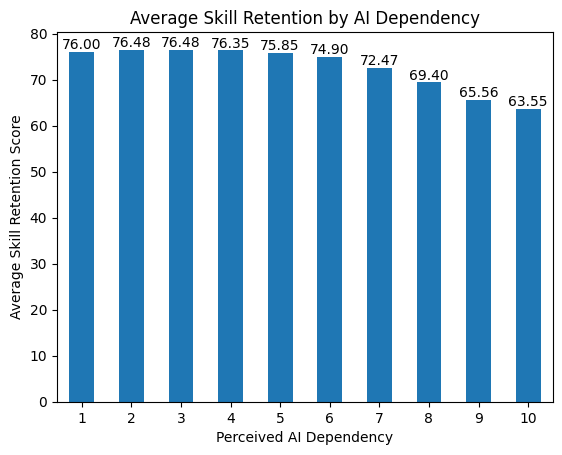

In [97]:
skill_by_dependency = df.groupby(
    'Perceived_AI_Dependency'
)['Skill_Retention_Score'].mean()

skill_by_dependency.plot(kind='bar')

plt.title('Average Skill Retention by AI Dependency')
plt.xlabel('Perceived AI Dependency')
plt.ylabel('Average Skill Retention Score')
plt.xticks(rotation=0)
plt.bar_label(plt.gca().containers[0], fmt='%.2f')
plt.show()

In [98]:
df['Perceived_AI_Dependency'].value_counts().sort_index()

Perceived_AI_Dependency
1      7303
2      8874
3     10478
4      9934
5      6745
6      3521
7      1722
8       855
9       378
10      190
Name: count, dtype: int64

These results show that people who have a low AI dependancy tend to have a steady skill retention score. However as the dependancy increases the skill retention drops  among students who reporder a dependancy of 8-10. Also the number or students who reported a dependancy of 8-10 also decreases so the results need to be with caution.

Can GPA change be predicted using the students AI usage, traditional study time and pre-semester GPA?

In [99]:
from sklearn.model_selection import train_test_split

In [101]:
X = df[['Weekly_GenAI_Hours',
        'Traditional_Study_Hours',
        'Pre_Semester_GPA']]

y = df['GPA_Change']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40000, 3)
Testing set: (10000, 3)


In [103]:
from sklearn.linear_model import LinearRegression

In [104]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [105]:
y_pred = model.predict(X_test)

/Users/loryvechiu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/loryvechiu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/loryvechiu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [106]:
comparison = pd.DataFrame({
    'Actual GPA Change': y_test,
    'Predicted GPA Change': y_pred
})

comparison.head(10)

,Actual GPA Change,Predicted GPA Change
33553,0.374,0.196020
9427,0.521,0.215868
199,0.161,0.248964
12447,0.237,0.086234
39489,0.157,0.132173
42724,-0.105,0.233573
10822,0.628,0.201767
49498,0.007,0.205520
4144,0.213,0.192023
36958,0.177,0.175285


In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
aspe = mean_absolute_error(y_test, y_pred)  #average size of prediction error
LE = mean_squared_error(y_test, y_pred) ** 0.5  #large errors 
V = r2_score(y_test, y_pred)   #how much of the variation in GPA change the model explains

print("ASPE:", mae)
print("LE:", rmse)
print("V:", r2)

ASPE: 0.1327084709376203
LE: 0.1709807871315024
V: 0.1493066836110869


In [110]:
coefficients = pd.Series(
    model.coef_,
    index=X.columns
)

coefficients

Weekly_GenAI_Hours         0.000297
Traditional_Study_Hours    0.013771
Pre_Semester_GPA          -0.038995
dtype: float64